<a href="https://colab.research.google.com/github/talgiladi/Portfolio/blob/main/PyTorch_TensorBoard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.tensorboard import SummaryWriter

import tensorflow as tf
import tensorboard as tb
tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.98MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.85MB/s]


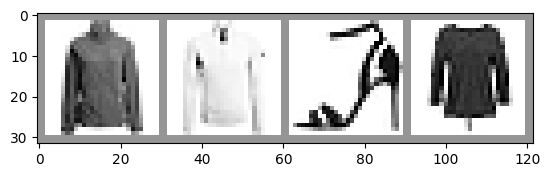

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

training_set = torchvision.datasets.FashionMNIST('./data',
                                                 download = True,
                                                 train = True,
                                                 transform = transform)
validation_set = torchvision.datasets.FashionMNIST('./data',
                                                   download = True,
                                                   train = False,
                                                   transform = transform)
training_loader = torch.utils.data.DataLoader(training_set,
                                              batch_size = 4,
                                              shuffle = True,
                                              num_workers = 2)
validation_loader = torch.utils.data.DataLoader(validation_set,
                                                batch_size = 4,
                                                shuffle= False,
                                                num_workers = 2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

def matplotlib_imshow(img, one_channel = False):
  if one_channel:
    img = img.mean(dim = 0)
  img = img / 2 +0.5
  npimg = img.numpy()
  if one_channel:
    plt.imshow(npimg, cmap = "Greys")
  else:
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

In [ ]:
#https://chatgpt.com/c/67f90994-cd0c-800e-b88e-128ce153985d
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn .Conv2d(1,6,5)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 4 * 4, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 4 * 4)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 1
for epoch in range(epochs):
  running_loss = 0.0
  for i, data in enumerate(training_loader, 0):
    optimizer.zero_grad()
    inputs, labels = data
    outputs = net(inputs)
    loss = criterion(input = outputs, target = labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    if (i%1000 == 999):
      print(f"Batch {i+1}")
      running_vloss = 0.0
      net.eval()
      with torch.inference_mode():
        for j, vdata in enumerate(validation_loader, 0):
          vinputs, vlabels = vdata
          v_outputs = net(vinputs)
          v_loss = criterion(v_outputs, vlabels)
          running_vloss += v_loss.item()

      avg_loss = running_loss/1000
      avg_vloss = running_vloss/1000
      print(f"Training loss {avg_loss}, Validation loss {avg_vloss}")
      net.train()
      running_loss = 0.0

print("Finished training")


Batch 1000
Training loss 1.8845942929536104, Validation loss 2.6349054392799736
Batch 2000
Training loss 0.8891788139450364, Validation loss 1.846312908812426
Batch 3000
Training loss 0.6940465323696844, Validation loss 1.7602451440906153
Batch 4000
Training loss 0.6524758185590618, Validation loss 1.6048676922512242
Batch 5000
Training loss 0.5895802677550237, Validation loss 1.4472446396223968
Batch 6000
Training loss 0.5486364961753134, Validation loss 1.3549829024012434
Batch 7000
Training loss 0.537146611717646, Validation loss 1.2847024577311823
Batch 8000
Training loss 0.5041421928086783, Validation loss 1.253563197287207
Batch 9000
Training loss 0.4669373314115219, Validation loss 1.3252837937990845
Batch 10000
Training loss 0.4702618756435113, Validation loss 1.168403525868198
Batch 11000
Training loss 0.4451519081136794, Validation loss 1.1217468168816414
Batch 12000
Training loss 0.4549133396926918, Validation loss 1.1050089752170025
Batch 13000
Training loss 0.4120821207796